# Quick Analysis of the Results

In [1]:
from copy import deepcopy
from pathlib import Path

import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker

pd.options.display.float_format = '{:,.4f}'.format
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

%matplotlib inline

## View the results in a single table

In [2]:
library_path = Path("library").resolve()
results = pd.read_csv(library_path / "results" / "outputs_v2.csv", index_col="Metrics")
results_projects = results.loc[
    ~results.index.isin(("Whole project or phase", "Short name")),
    results.loc["Whole project or phase"] == "project"
]
results_projects

,Revolution Wind,CVOW C,Sunrise Wind,Kitty Hawk North,US Wind,New England,Empire Wind,Atlantic Shores South,Southcoast Wind,Ocean Wind 1
Metrics,,,,,,,,,,
# Turbines,79,176,102,69,114,128,139,200,147,98
Turbine Rating (MW),11,15,11,15,15,16,15,15,15,12
Project Capacity (MW),869,2640,1122,1035,1710,2048,2085,3000,2205,1176
# OSS,2,3,1,1,4,2,2,3,2,3
Total Export Cable Length (km),229.0341,594.25776,394.09504,294.10479,232.10016,770.3577,540.2792,604.19488,588.25295,237.0791453
Total Array Cable Length (km),186.9965011,354.9486935,296.3929973,251.1395799,200.5584032,343.4463559,310.3039215,346.6873441,386.9290152,208.0795875
FCR,0.0582,0.0582,0.0582,0.0582,0.0582,0.0582,0.0582,0.0582,0.0582,0.0582
offtake price ($/MWh),99.03,89.06,83.3,89.06,86.7,75.07,97.99,58.8,64.56,116.8
CapEx ($),2994396588,7813031773,3751881179,3591735600,5192854896,6761130069,6319721994,9324020799,7452923653,3778849941


## How does the size

In [3]:
exclude = ["Whole project or phase", "Short name", "FCR", "DNV (2022) - Fixed North America (2022 LCOE value in $2021)", "BNEF (2022) - USA (high)  (2022 LCOE value in $2021)"]
considered_metrics = list(set(results.index.values).difference(exclude))

In [4]:
corr_df = pd.concat(
    [
        pd.DataFrame(
            [
                scipy.stats.pearsonr(results.loc[variable].astype(float), results.loc[ix].astype(float)).statistic
                if results.loc[ix].isna().sum() == 0 else np.nan
                for ix in considered_metrics
            ],
            index=[considered_metrics],
            columns=[variable],
        )
        for variable in considered_metrics
    ],
    axis=1
)

In [5]:
corr_df

,Distance to landfall (km),Annual OpEx per kW ($/kW/yr),Depth (m),OpEx per kW ($/kW),# OSS,IRR (%),CapEx without export cable CapEx ($),CapEx ($),"net CF (%) (only considers availability, not losses)",OpEx ($),# Turbines,NPV ($),real net CF (%) (considers losses and availability),Total Array Cable Length (km),offtake price ($/MWh),Distance to port (km),Availability (%),Project Capacity (MW),System CapEx for export cables ($),Installation CapEx for export cables ($),CapEx per kW ($/kW),AEP per kW (MWh/kW) (considers losses and availability),Turbine Rating (MW),gross CF (%) (does not consider losses),Total Export Cable Length (km),AEP (MWh) (considers losses and availability),Annual losses (MWh),LCOE ($/MWh),Mean wind speed (m/s)
Distance to landfall (km),1.0000,-0.0967,0.7166,-0.0967,-0.4606,0.0744,-0.0336,-0.0367,0.6277,-0.0048,-0.0627,0.0504,0.6295,0.2157,-0.2966,-0.2961,0.2098,-0.1037,-0.0579,-0.0200,0.5075,0.6295,-0.1911,0.6083,0.3175,0.0737,0.0726,-0.4580,0.6087
Annual OpEx per kW ($/kW/yr),-0.0967,1.0000,-0.1568,1.0000,-0.4487,-0.0137,-0.8281,-0.8294,0.0485,-0.6336,-0.8155,0.8222,0.0388,-0.7930,0.4643,0.5447,-0.7163,-0.8281,-0.6725,-0.6279,0.5424,0.0388,-0.1445,0.1301,-0.7651,-0.8032,-0.7515,0.6709,0.0066
Depth (m),0.7166,-0.1568,1.0000,-0.1568,-0.4209,0.2085,0.0609,0.0511,0.7754,0.1264,-0.0453,-0.0255,0.7767,0.3182,-0.2574,-0.3091,0.1796,-0.0294,-0.0553,0.1688,0.4804,0.7767,0.1031,0.7586,0.4138,0.2130,0.2383,-0.6045,0.7808
OpEx per kW ($/kW),-0.0967,1.0000,-0.1568,1.0000,-0.4487,-0.0137,-0.8281,-0.8294,0.0485,-0.6336,-0.8155,0.8222,0.0388,-0.7930,0.4643,0.5447,-0.7163,-0.8281,-0.6725,-0.6279,0.5424,0.0388,-0.1445,0.1301,-0.7651,-0.8032,-0.7515,0.6709,0.0066
# OSS,-0.4606,-0.4487,-0.4209,-0.4487,1.0000,0.0944,0.6032,0.6005,-0.3430,0.6199,0.6710,-0.5928,-0.3420,0.4425,0.0259,0.1995,0.0220,0.6395,0.4612,0.3447,-0.6379,-0.3420,-0.1272,-0.3494,0.2601,0.5178,0.5407,-0.1204,-0.3152
IRR (%),0.0744,-0.0137,0.2085,-0.0137,0.0944,1.0000,0.0012,-0.0165,0.4687,-0.1207,0.0648,0.0805,0.4709,0.2080,0.7530,-0.3709,0.2379,-0.0078,-0.1675,-0.1005,-0.0042,0.4709,-0.3872,0.4470,0.1568,0.0917,0.0522,-0.4661,0.4451
CapEx without export cable CapEx ($),-0.0336,-0.8281,0.0609,-0.8281,0.6032,0.0012,1.0000,0.9977,-0.0480,0.8338,0.9775,-0.9941,-0.0425,0.8884,-0.4032,-0.2280,0.4250,0.9946,0.7753,0.7395,-0.5359,-0.0425,0.1767,-0.0946,0.8173,0.9722,0.9522,-0.5769,0.0290
CapEx ($),-0.0367,-0.8294,0.0511,-0.8294,0.6005,-0.0165,0.9977,1.0000,-0.0425,0.8283,0.9751,-0.9973,-0.0368,0.8855,-0.4205,-0.2279,0.4334,0.9933,0.8162,0.7758,-0.5078,-0.0368,0.1796,-0.0900,0.8239,0.9725,0.9509,-0.5761,0.0339
"net CF (%) (only considers availability, not losses)",0.6277,0.0485,0.7754,0.0485,-0.3430,0.4687,-0.0480,-0.0425,1.0000,0.0196,-0.0783,0.0815,0.9999,0.2303,-0.0116,-0.2452,0.1011,-0.1229,0.0049,0.1522,0.6578,0.9999,-0.2445,0.9936,0.2691,0.1616,0.1854,-0.6781,0.9867
OpEx ($),-0.0048,-0.6336,0.1264,-0.6336,0.6199,-0.1207,0.8338,0.8283,0.0196,1.0000,0.8280,-0.8265,0.0201,0.7767,-0.4516,0.1196,0.0488,0.8057,0.6153,0.5541,-0.3735,0.0201,-0.0417,0.0149,0.5736,0.8178,0.8848,-0.4573,0.1067


In [6]:
s = results_projects.select_dtypes(include='object').columns
results_projects[s] = results_projects[s].astype("float")
results_projects.T.describe().T

,count,mean,std,min,25%,50%,75%,max
Metrics,,,,,,,,
# Turbines,10.0000,125.2000,41.5607,69.0000,99.0000,121.0000,145.0000,200.0000
Turbine Rating (MW),10.0000,14.0000,1.8856,11.0000,12.7500,15.0000,15.0000,16.0000
Project Capacity (MW),10.0000,"1,789.0000",727.2696,869.0000,"1,135.5000","1,879.0000","2,175.0000","3,000.0000"
# OSS,10.0000,2.3000,0.9487,1.0000,2.0000,2.0000,3.0000,4.0000
Total Export Cable Length (km),10.0000,448.3756,195.3696,229.0341,251.3356,467.1871,592.7566,770.3577
Total Array Cable Length (km),10.0000,288.5482,72.2236,186.9965,218.8446,303.3485,345.8771,386.9290
FCR,10.0000,0.0582,0.0000,0.0582,0.0582,0.0582,0.0582,0.0582
offtake price ($/MWh),10.0000,86.0370,17.0217,58.8000,77.1275,87.8800,95.7575,116.8000
CapEx ($),10.0000,"5,698,054,649.2000","2,152,245,213.6625","2,994,396,588.0000","3,758,623,369.5000","5,756,288,445.0000","7,279,975,257.0000","9,324,020,799.0000"


In [7]:
layouts = library_path / "project/plant"
layout_order_list = []
for layout in layouts.iterdir():
    if not layout.stem.endswith("_base") or layout.suffix != ".csv":
        continue
    layout_df = pd.read_csv(layout)
    layout_order_list.append([layout.stem.replace("_layout_base", ""), layout_df.latitude.mean(), layout_df.longitude.mean()])
layout_order_df = pd.DataFrame(layout_order_list, columns=["project", "lat", "lon"]).sort_values("lat", ascending=False).reset_index(drop=True)
layout_order_df.project = layout_order_df.project.str.replace("_", " ").str.title()
layout_order_df.loc[layout_order_df.project == "Cvow C", "project"] = "CVOW C"
layout_order_df.loc[layout_order_df.project == "Us Wind", "project"] = "US Wind"
layout_order_df.loc[layout_order_df.project == "Mayflower Wind 1", "project"] = "Southcoast Wind 1"
layout_order_df.loc[layout_order_df.project == "Mayflower Wind 2", "project"] = "Southcoast Wind 2"
layout_order_df.loc[layout_order_df.project == "Mayflower Wind", "project"] = "Southcoast Wind"
layout_order_projects_df = layout_order_df.loc[layout_order_df.project.isin(results_projects.columns)].reset_index(drop=True)

# Put the phases on top of the full project
a, b = layout_order_df.iloc[6].copy(), layout_order_df.iloc[7].copy()
layout_order_df.iloc[6], layout_order_df.iloc[7] = b, a

a, b = layout_order_df.iloc[3].copy(), layout_order_df.iloc[4].copy()
layout_order_df.iloc[3], layout_order_df.iloc[4] = b, a

a, b = layout_order_df.iloc[9].copy(), layout_order_df.iloc[10].copy()
layout_order_df.iloc[9], layout_order_df.iloc[10] = b, a

a, b, c = layout_order_df.iloc[11].copy(), layout_order_df.iloc[12].copy(), layout_order_df.iloc[13].copy()
layout_order_df.iloc[11], layout_order_df.iloc[12], layout_order_df.iloc[13] = c, a, b

a, b, c, d = layout_order_df.iloc[15].copy(), layout_order_df.iloc[16].copy(), layout_order_df.iloc[17].copy(), layout_order_df.iloc[18].copy()
layout_order_df.iloc[15], layout_order_df.iloc[16], layout_order_df.iloc[17], layout_order_df.iloc[18] = d, c, a, b

layout_order_df

,project,lat,lon
0,Revolution Wind,41.1576,-71.0636
1,Sunrise Wind,40.9876,-71.0665
2,Park City,40.9612,-70.5774
3,Commonwealth,40.8650,-70.6957
4,New England,40.9027,-70.6493
5,Southcoast Wind 1,40.8037,-70.3340
6,Southcoast Wind 2,40.6885,-70.5043
7,Southcoast Wind,40.7511,-70.4117
8,Empire Wind 1,40.3259,-73.4069
9,Empire Wind 2,40.2636,-73.2192


In [8]:
layout_order_projects_df

,project,lat,lon
0,Revolution Wind,41.1576,-71.0636
1,Sunrise Wind,40.9876,-71.0665
2,New England,40.9027,-70.6493
3,Southcoast Wind,40.7511,-70.4117
4,Empire Wind,40.2879,-73.2924
5,Atlantic Shores South,39.2733,-74.0924
6,Ocean Wind 1,39.1144,-74.2425
7,US Wind,38.3389,-74.7566
8,CVOW C,36.9020,-75.3480
9,Kitty Hawk North,36.3871,-75.2196


## LCOE Comparison by Phase and Whole Project

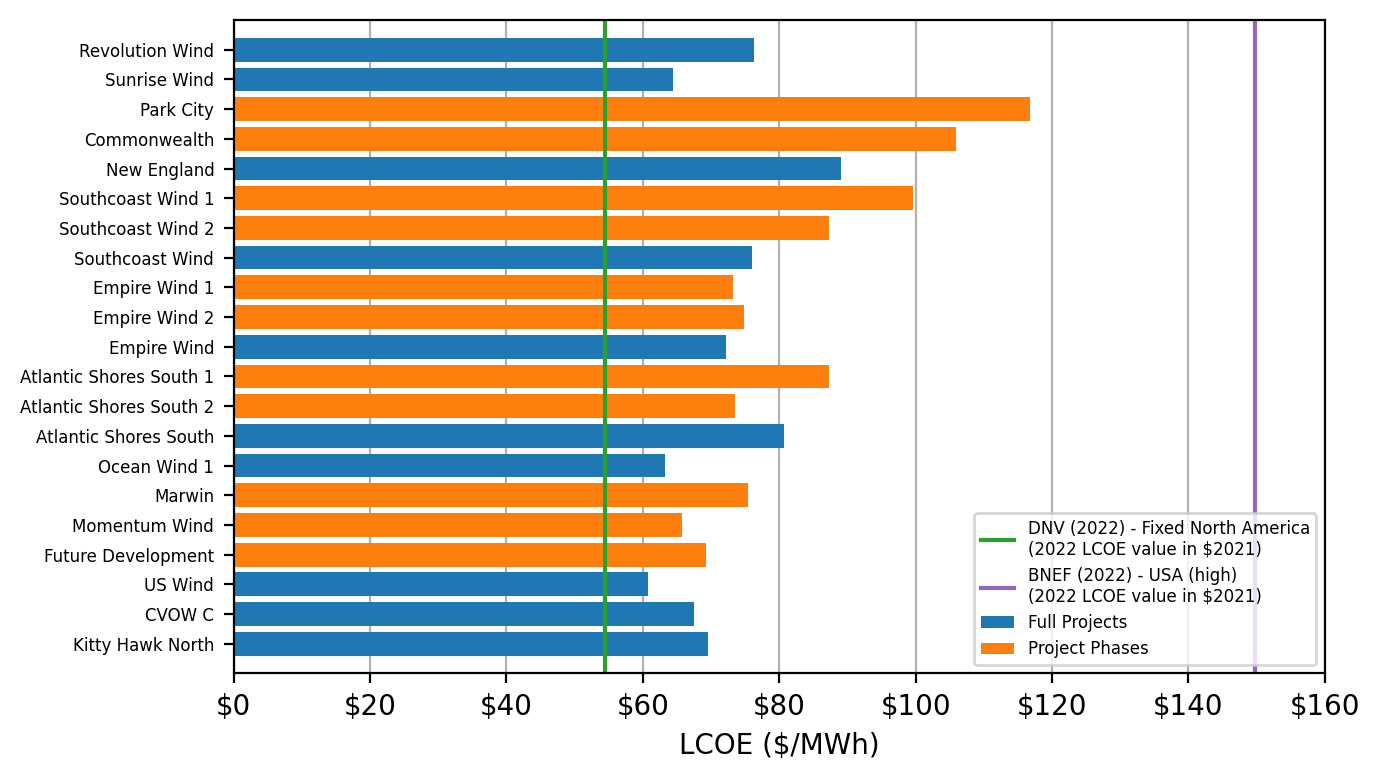

In [9]:
# LCOE bar graph by project with a min-max range LCOE 2021USD values from the OWMR – since the outputs of 
# WHaLe are not projected by COD,  I would just compare it to the 2021USD ranges we have in the OWMR for
# the 2022 year. I would do something similar to this plot:LCOE by project in a bar graph and min and max
# LCOE ranges in the horizontal lines.

fig = plt.figure(dpi=200, figsize=(7, 4))
ax = fig.add_subplot(111)

layout_order = layout_order_df.project.values.tolist()
layout_project_order = layout_order_projects_df.project.values.tolist()
layout_phase_order = [el for el in layout_order_df.project if el not in layout_project_order]

y_project = [layout_order.index(el) for el in layout_project_order]
bar_project = results.loc["LCOE ($/MWh)", layout_project_order].values.astype(float)

y_phase = [layout_order.index(el) for el in layout_phase_order]
bar_phase = results.loc["LCOE ($/MWh)", layout_phase_order].values.astype(float)

ax.barh([20 - y for y in y_project], bar_project[::-1], label="Full Projects")
ax.barh([20 - y for y in y_phase], bar_phase[::-1], label="Project Phases")


ax.axvline(54.4487, -1, 11, c="tab:green", label="DNV (2022) - Fixed North America\n(2022 LCOE value in $2021)")
ax.axvline(149.7300, -1, 11, c="tab:purple", label="BNEF (2022) - USA (high)\n(2022 LCOE value in $2021)")

ax.set_ylim(-1, 21)
ax.set_yticks(list(range(21)))
labels = deepcopy(layout_order)
# labels[-1] = "Kitty Hawk\nNorth"
# labels[-5] = "Atlantic Shores\nSouth"
ax.set_yticklabels(labels[::-1], fontsize=6)

ax.set_xlabel("LCOE ($/MWh)")
ax.set_xlim(0, 160)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))

ax.grid(axis="x")
ax.set_axisbelow(True)
ax.legend(loc="lower right", fontsize=6)

fig.tight_layout()
fig.savefig("library/results/figures/lcoe_comparison.svg")
fig.savefig("library/results/figures/lcoe_comparison.png")

## Capacity Factor vs Mean ERA5 Windspeed

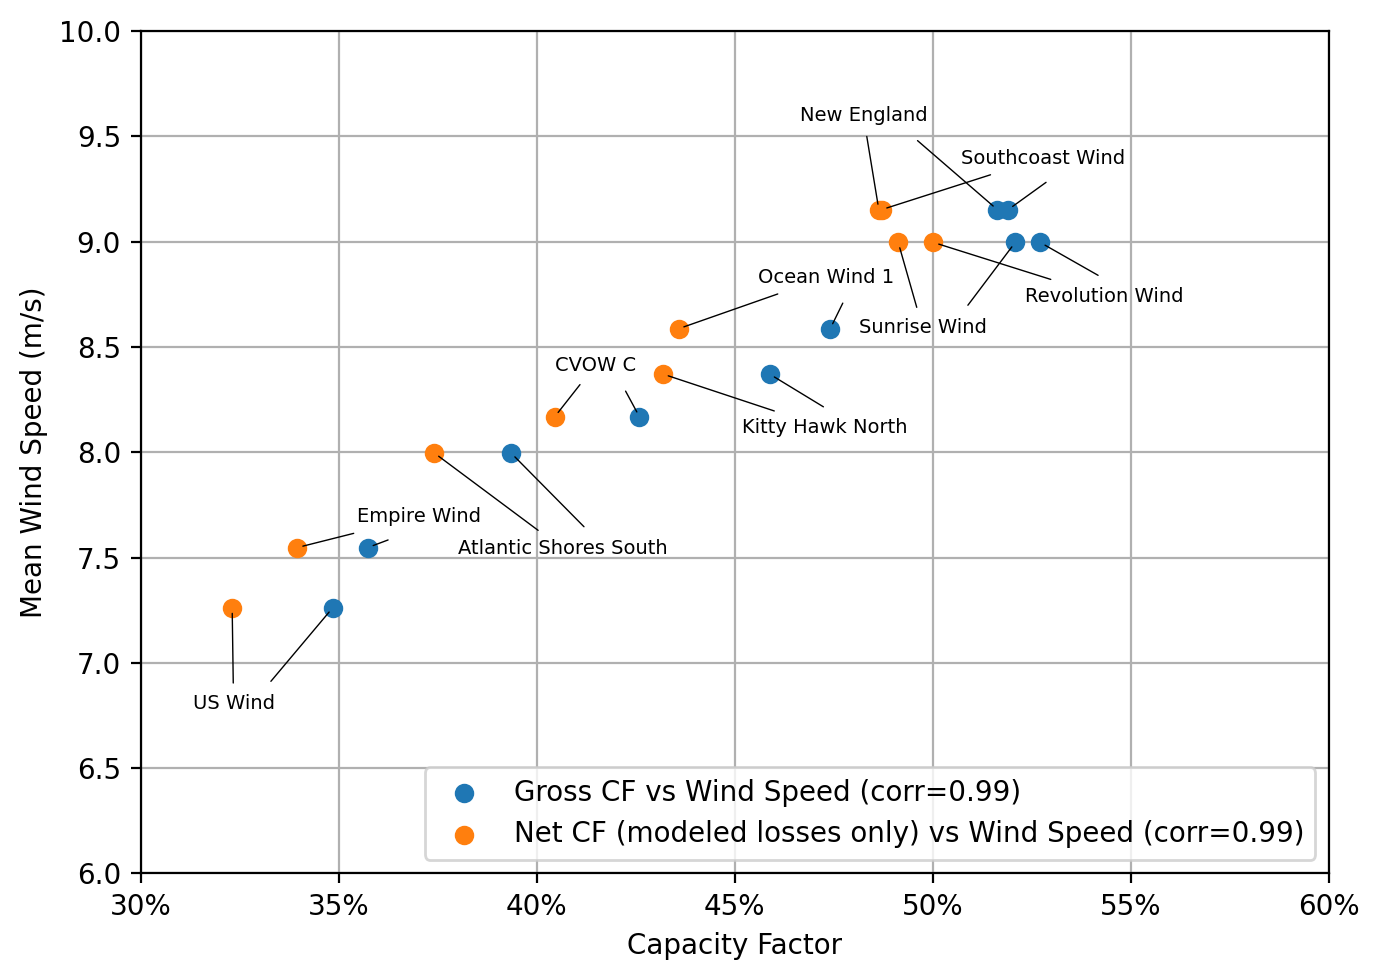

In [10]:
fig = plt.figure(dpi=200, figsize=(7, 5))
ax = fig.add_subplot(111)

x = "gross CF (%) (does not consider losses)"
y = "Mean wind speed (m/s)"
data_x1 = results_projects.loc[x].astype(float)
data_y = results_projects.loc[y].astype(float)
data_labels = results_projects.columns
ax.scatter(
    data_x1,
    data_y,
    label=f"Gross CF vs Wind Speed (corr={corr_df.loc[y, x].values[0]:.2f})"
)   

x = "net CF (%) (only considers availability, not losses)"
y = "Mean wind speed (m/s)"
data_x2 = results_projects.loc[x].astype(float)
data_y = results_projects.loc[y].astype(float)
data_labels = results_projects.columns
ax.scatter(
    data_x2,
    data_y,
    label=f"Net CF (modeled losses only) vs Wind Speed (corr={corr_df.loc[y, x].values[0]:.2f})"
)

for _x1, _x2, _y, _name in zip(data_x1, data_x2, data_y, data_labels):
    x_shift = 0.01
    y_shift = 0.1
    if _name == "US Wind":
        x_shift = -0.01
        y_shift = -0.5
    elif _name == "Empire Wind":
        x_shift = 0.015
    elif _name == "Atlantic Shores South":
        x_shift = 0.006
        y_shift = -0.5
    elif _name == "Kitty Hawk North":
        x_shift = 0.02
        y_shift = -0.3
    elif _name == "Ocean Wind 1":
        x_shift = 0.02
        y_shift = 0.2
    elif _name == "New England":
        x_shift = -0.02
        y_shift = 0.4
    elif _name == "Revolution Wind":
        x_shift = 0.023
        y_shift = -0.3
    elif _name == "Sunrise Wind":
        x_shift = -0.01
        y_shift = -0.45
    elif _name == "Southcoast Wind":
        x_shift = 0.02
        y_shift = 0.2
    elif _name == "CVOW C":
        x_shift = 0
        y_shift = 0.2
    ax.annotate(_name, (_x1, _y), (_x2 + x_shift, _y + y_shift), color="none", arrowprops={"arrowstyle": "-", "linewidth": 0.5})
    ax.annotate(_name, (_x2, _y), (_x2 + x_shift, _y + y_shift), ha="left", va="bottom", fontsize=7, arrowprops={"arrowstyle": "-", "linewidth": 0.5})

ax.set_xlabel("Capacity Factor")
ax.set_ylabel("Mean Wind Speed (m/s)")

ax.set_xlim(0.3, 0.6)
ax.set_ylim(6, 10)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0%}"))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.1f}"))

ax.grid()
ax.set_axisbelow(True)
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig("library/results/figures/cf_vs_windspeed.svg")
fig.savefig("library/results/figures/cf_vs_windspeed.png")

## Distance to Shore vs CapEx

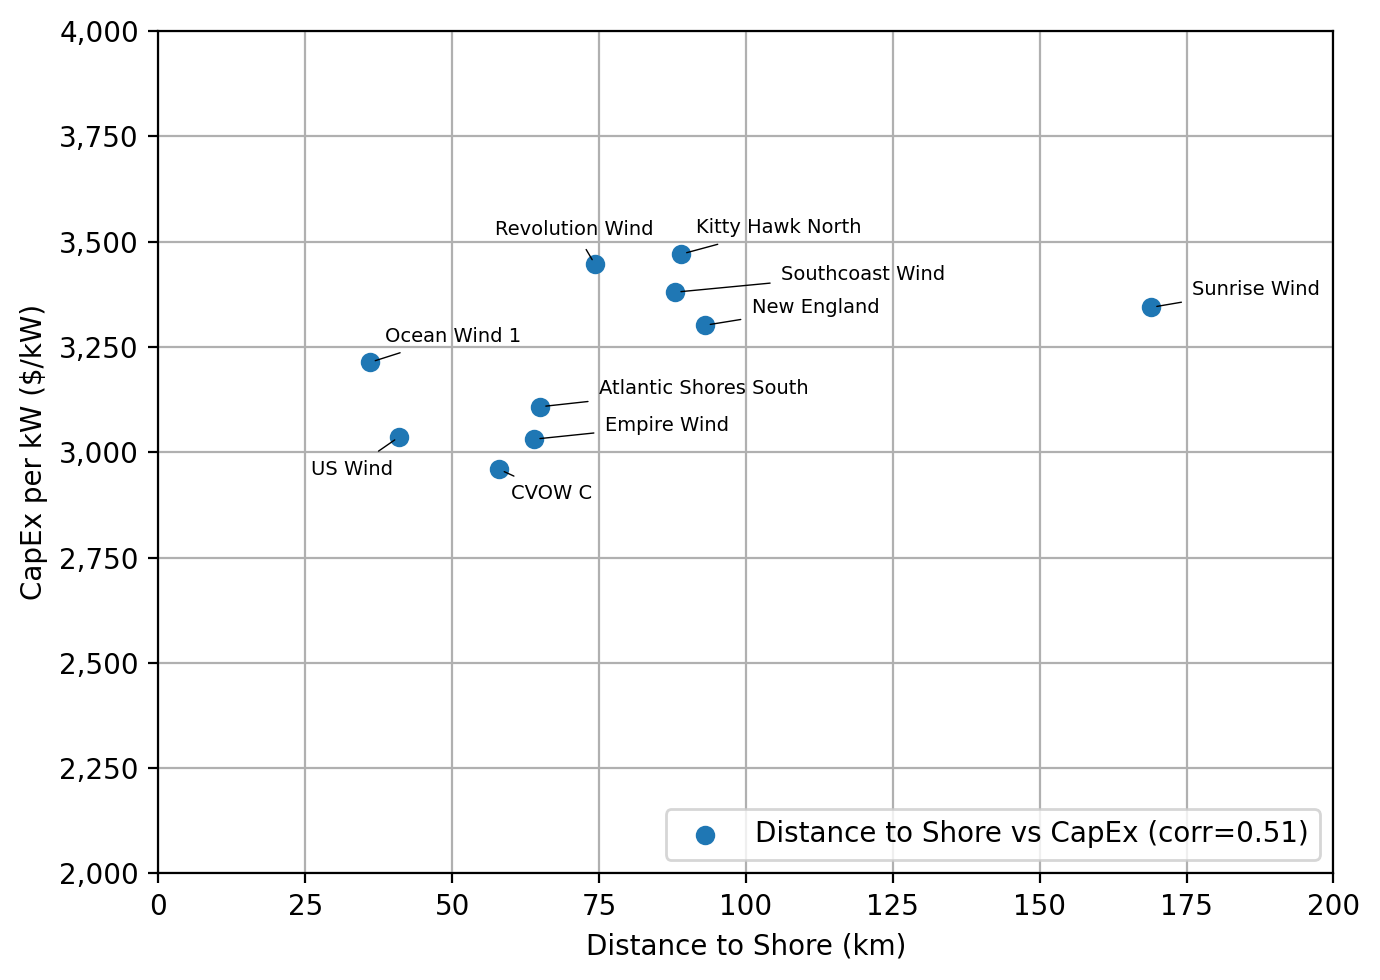

In [11]:
fig = plt.figure(dpi=200, figsize=(7, 5))
ax = fig.add_subplot(111)

x = "Distance to landfall (km)"
y = "CapEx per kW ($/kW)"
data_x = results_projects.loc[x].astype(float)
data_y = results_projects.loc[y].astype(float)
data_labels = results_projects.columns
ax.scatter(
    data_x,
    data_y,
    label=f"Distance to Shore vs CapEx (corr={corr_df.loc[y, x].values[0]:.2f})"
)

for _x, _y, _name in zip(data_x, data_y, data_labels):
    x_shift = 2
    y_shift = 20
    if _name == "Revolution Wind":
        x_shift = -17
        y_shift = 60
    elif _name == "Sunrise Wind":
        x_shift = 7
    elif _name == "Southcoast Wind":
        x_shift = 18
    elif _name == "Kitty Hawk North":
        x_shift = 2.5
        y_shift = 40
    elif _name == "Empire Wind":
        x_shift = 12
        y_shift = 10
    elif _name == "Ocean Wind 1":
        y_shift = 40
        x_shift = 2.5
    elif _name == "CVOW C":
        y_shift = -80
    elif _name == "US Wind":
        x_shift = -15
        y_shift = -100
    elif _name == "Atlantic Shores South":
        x_shift = 10
    elif _name == "New England":
        x_shift = 8
    ax.annotate(_name, (_x, _y), (_x + x_shift, _y + y_shift), ha="left", va="bottom", fontsize=7, arrowprops={"arrowstyle": "-", "linewidth": 0.5})

ax.set_xlabel("Distance to Shore (km)")
ax.set_ylabel(y)
ax.set_ylim(2000, 4000)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

ax.set_xlim(0, 200)
ax.grid()
ax.set_axisbelow(True)
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig("library/results/figures/shore_distance_vs_capex.svg")
fig.savefig("library/results/figures/shore_distance_vs_capex.png")

## Depth vs CapEx

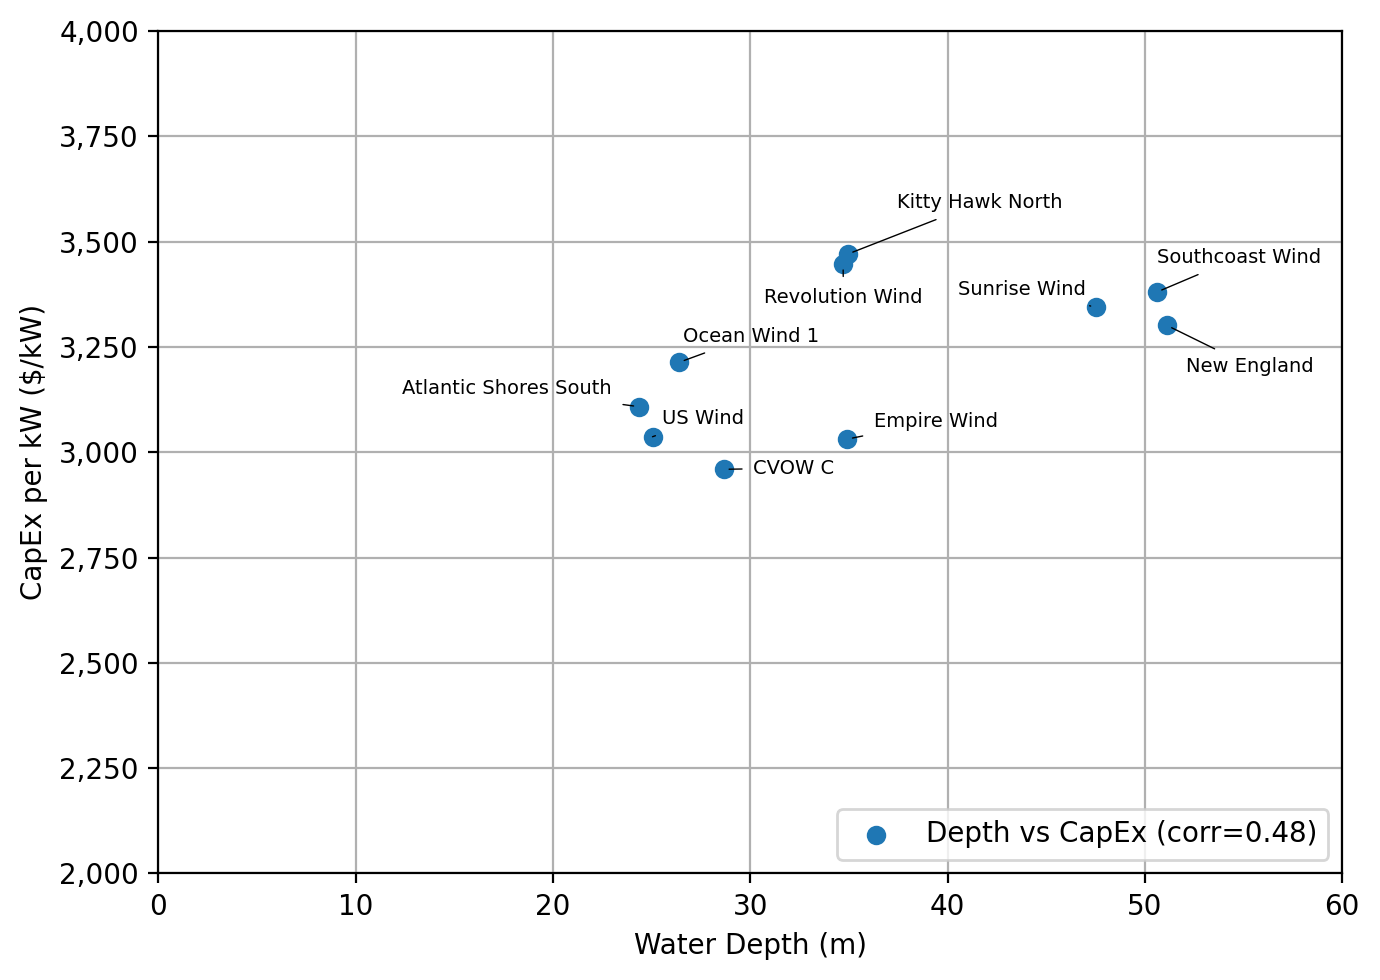

In [12]:
fig = plt.figure(dpi=200, figsize=(7, 5))
ax = fig.add_subplot(111)

x = "Depth (m)"
y = "CapEx per kW ($/kW)"
data_x = results_projects.loc[x].astype(float)
data_y = results_projects.loc[y].astype(float)
data_labels = results_projects.columns
ax.scatter(
    data_x,
    data_y,
    label=f"Depth vs CapEx (corr={corr_df.loc[y, x].values[0]:.2f})"
)

for _x, _y, _name in zip(data_x, data_y, data_labels):
    x_shift = 1
    y_shift = 20
    if _name == "Revolution Wind":
        x_shift = -4
        y_shift = -100
    elif _name == "Sunrise Wind":
        x_shift = -7
    elif _name == "Southcoast Wind":
        y_shift = 60
        x_shift = 0
    elif _name == "Kitty Hawk North":
        x_shift = 2.5
        y_shift = 100
    elif _name == "Empire Wind":
        x_shift = 1.35
    elif _name == "Ocean Wind 1":
        y_shift = 40
        x_shift = 0.2
    elif _name == "CVOW C":
        y_shift = -20
        x_shift = 1.5
    elif _name == "US Wind":
        x_shift = 0.5
    elif _name == "Atlantic Shores South":
        x_shift = -12
    elif _name == "New England":
        y_shift = -120
    ax.annotate(_name, (_x, _y), (_x + x_shift, _y + y_shift), ha="left", va="bottom", fontsize=7, arrowprops={"arrowstyle": "-", "linewidth": 0.5})

ax.set_xlabel("Water Depth (m)")
ax.set_ylabel(y)
ax.set_ylim(2000, 4000)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

ax.set_xlim(0, 60)
ax.grid()
ax.set_axisbelow(True)
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig("library/results/figures/depth_vs_capex.svg")
fig.savefig("library/results/figures/depth_vs_capex.png")

## Distance to Port vs OpEx

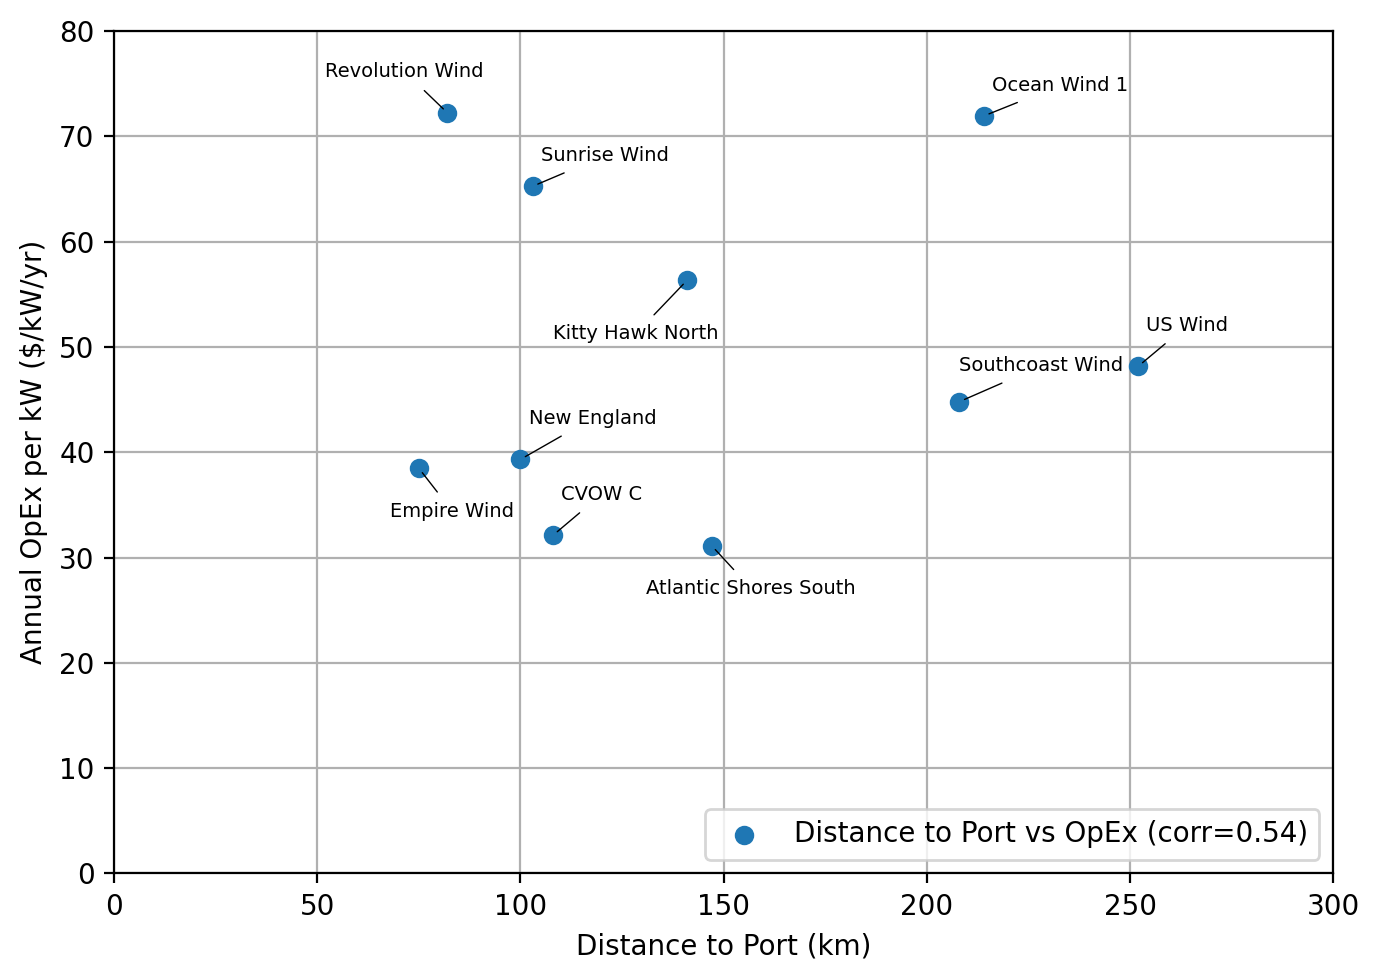

In [13]:
fig = plt.figure(dpi=200, figsize=(7, 5))
ax = fig.add_subplot(111)

x = "Distance to port (km)"
y = "Annual OpEx per kW ($/kW/yr)"
data_x = results_projects.loc[x].astype(float)
data_y = results_projects.loc[y].astype(float)
data_labels = results_projects.columns
ax.scatter(
    data_x,
    data_y,
    label=f"Distance to Port vs OpEx (corr={corr_df.loc[y, x].values[0]:.2f})"
)

for _x, _y, _name in zip(data_x, data_y, data_labels):
    x_shift = 2
    y_shift = 3
    if _name == "Revolution Wind":
        x_shift = -30
    elif _name == "Sunrise Wind":
        y_shift = 2
    elif _name == "Southcoast Wind":
        x_shift = 0
        y_shift = 2.5
    elif _name == "Kitty Hawk North":
        x_shift = -33
        y_shift = -6
    elif _name == "Empire Wind":
        x_shift = -7
        y_shift = -5
    elif _name == "Ocean Wind 1":
        y_shift = 2
    elif _name == "Commonwealth":
        y_shift = 2
    elif _name == "Atlantic Shores South":
        x_shift = -16
        y_shift = -5
    ax.annotate(_name, (_x, _y), (_x + x_shift, _y + y_shift), ha="left", va="bottom", fontsize=7, arrowprops={"arrowstyle": "-", "linewidth": 0.5})

ax.set_xlabel("Distance to Port (km)")
ax.set_ylabel(y)
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

ax.set_xlim(0, 300)
ax.grid()
ax.set_axisbelow(True)
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig("library/results/figures/port_distance_vs_opex.svg")
fig.savefig("library/results/figures/port_distance_vs_opex.png")

## Correlation Exploration

/var/folders/q5/tfpytqxn0r396dfg7rk5sj8rwq9tvv/T/ipykernel_6635/3059686098.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels([f"{el:,.0f}" for el in ax1.get_yticks()])
/var/folders/q5/tfpytqxn0r396dfg7rk5sj8rwq9tvv/T/ipykernel_6635/3059686098.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax3.set_yticklabels([f"{el:.0%}" for el in ax3.get_yticks()])
/var/folders/q5/tfpytqxn0r396dfg7rk5sj8rwq9tvv/T/ipykernel_6635/3059686098.py:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_yticklabels([f"{el:,.0f}" for el in ax2.get_yticks()])
/var/folders/q5/tfpytqxn0r396dfg7rk5sj8rwq9tvv/T/ipykernel_6635/3059686098.py:47: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_yticklabels([f"{el:,.0f}" for el in ax4.get_yticks()])
/var/folders/q5/tfpytqxn0r396dfg7rk5sj8rwq9tvv/T/ipykernel_6635/3059686098.py:63: UserWarning: FixedFormatter sho

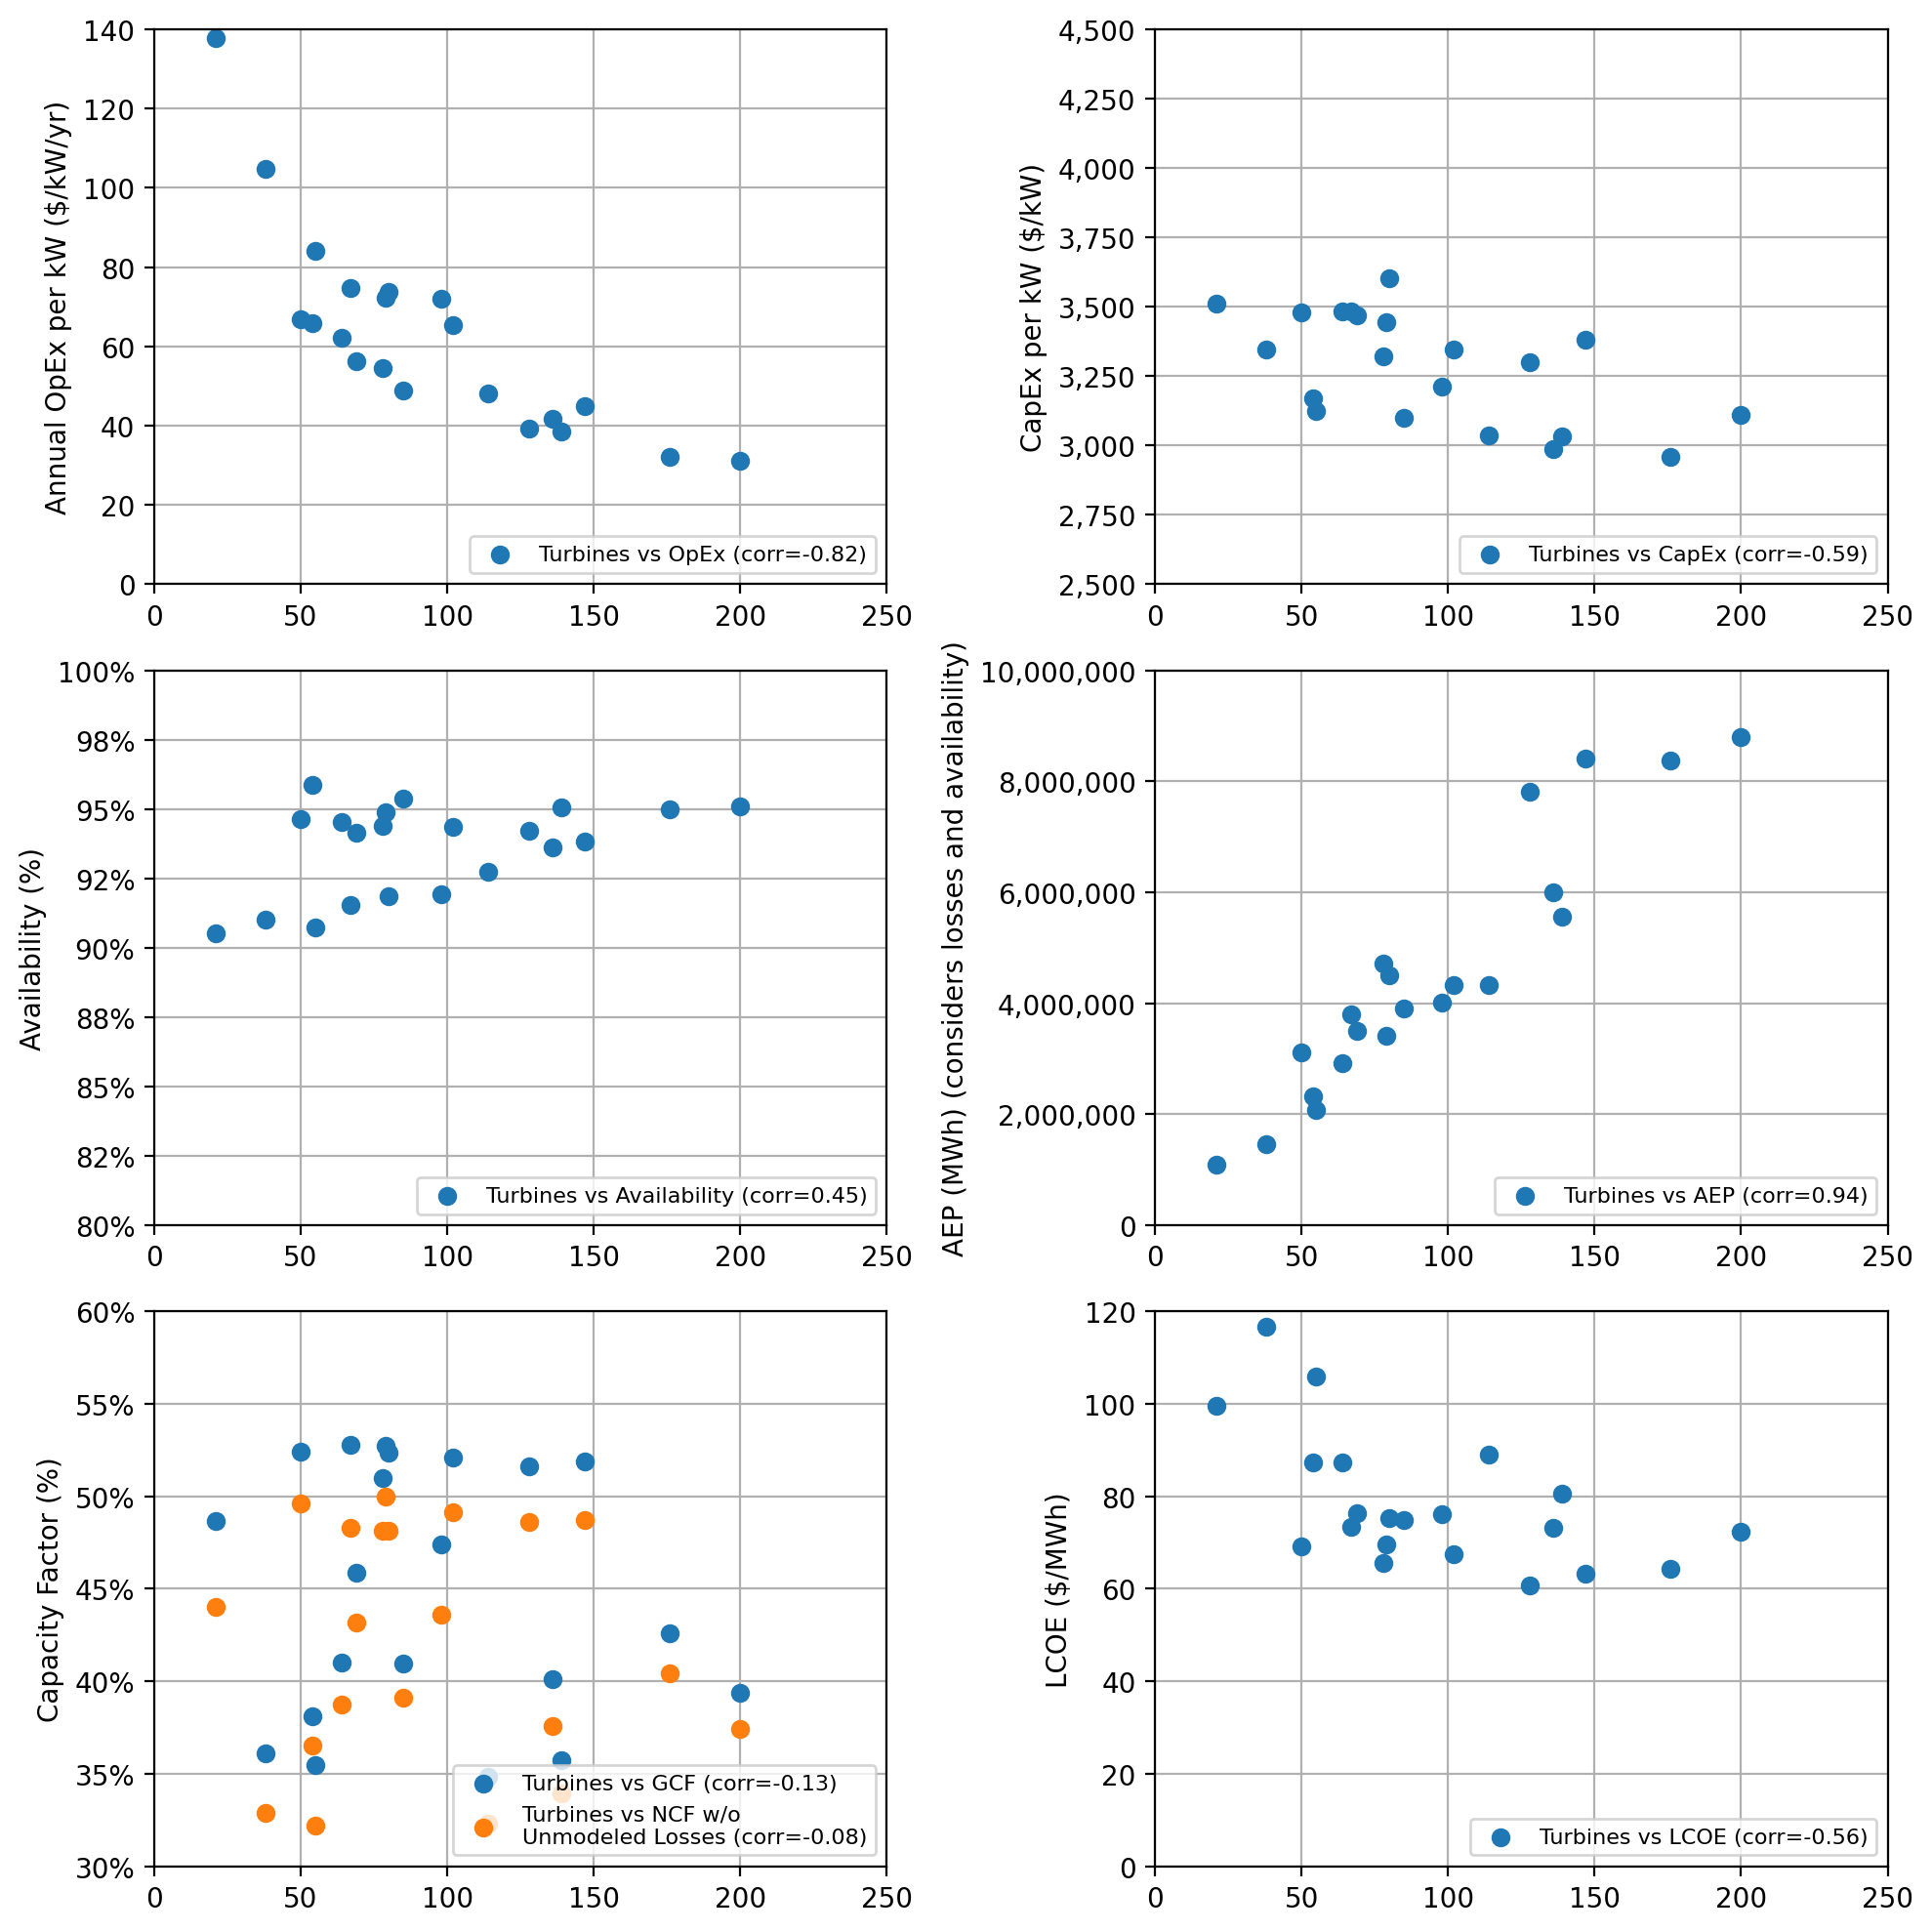

In [14]:
fig = plt.figure(dpi=200, figsize=(10, 10))
ax1 = fig.add_subplot(321)
ax2 = fig.add_subplot(322)
ax3 = fig.add_subplot(323)
ax4 = fig.add_subplot(324)
ax5 = fig.add_subplot(325)
ax6 = fig.add_subplot(326)

y = "Annual OpEx per kW ($/kW/yr)"
ax1.scatter(
    results.loc["# Turbines"].astype(float),
    results.loc[y].astype(float),
    label=f"Turbines vs OpEx (corr={corr_df.loc[y, '# Turbines'].values[0]:.2f})"
)
ax1.set_ylabel(y)
ax1.set_ylim(0, 140)
ax1.set_yticklabels([f"{el:,.0f}" for el in ax1.get_yticks()])

y = "Availability (%)"
ax3.scatter(
    results.loc["# Turbines"].astype(float),
    results.loc[y].astype(float),
    label=f"Turbines vs Availability (corr={corr_df.loc[y, '# Turbines'].values[0]:.2f})"
)
ax3.set_ylabel(y)
ax3.set_ylim(0.8, 1)
ax3.set_yticklabels([f"{el:.0%}" for el in ax3.get_yticks()])

y = "CapEx per kW ($/kW)"
ax2.scatter(
    results.loc["# Turbines"].astype(float),
    results.loc[y].astype(float),
    label=f"Turbines vs CapEx (corr={corr_df.loc[y, '# Turbines'].values[0]:.2f})"
)
ax2.set_ylabel(y)
ax2.set_ylim(2500, 4500)
ax2.set_yticklabels([f"{el:,.0f}" for el in ax2.get_yticks()])

y = "AEP (MWh) (considers losses and availability)"
ax4.scatter(
    results.loc["# Turbines"].astype(float),
    results.loc[y].astype(float),
    label=f"Turbines vs AEP (corr={corr_df.loc[y, '# Turbines'].values[0]:.2f})"
)
ax4.set_ylabel(y)
ax4.set_ylim(0, 10000000)
ax4.set_yticklabels([f"{el:,.0f}" for el in ax4.get_yticks()])

y = "gross CF (%) (does not consider losses)"
ax5.scatter(
    results.loc["# Turbines"].astype(float),
    results.loc[y].astype(float),
    label=f"Turbines vs GCF (corr={corr_df.loc[y, '# Turbines'].values[0]:.2f})"
)
y = "net CF (%) (only considers availability, not losses)"
ax5.scatter(
    results.loc["# Turbines"].astype(float),
    results.loc[y].astype(float),
    label=f"Turbines vs NCF w/o\nUnmodeled Losses (corr={corr_df.loc[y, '# Turbines'].values[0]:.2f})"
)
ax5.set_ylabel("Capacity Factor (%)")
ax5.set_ylim(0.3, 0.6)
ax5.set_yticklabels([f"{el:.0%}" for el in ax5.get_yticks()])

y = "LCOE ($/MWh)"
ax6.scatter(
    results.loc["# Turbines"].astype(float),
    results.loc[y].astype(float),
    label=f"Turbines vs LCOE (corr={corr_df.loc[y, '# Turbines'].values[0]:.2f})"
)
ax6.set_ylabel(y)
ax6.set_ylim(0, 120)
ax6.set_yticklabels([f"{el:,.0f}" for el in ax6.get_yticks()])


for ax in (ax1, ax2, ax3, ax4, ax5, ax6):
    ax.set_xlim(0, 250)
    ax.grid()
    ax.set_axisbelow(True)
    ax.legend(loc="lower right", fontsize=8)

fig.tight_layout()

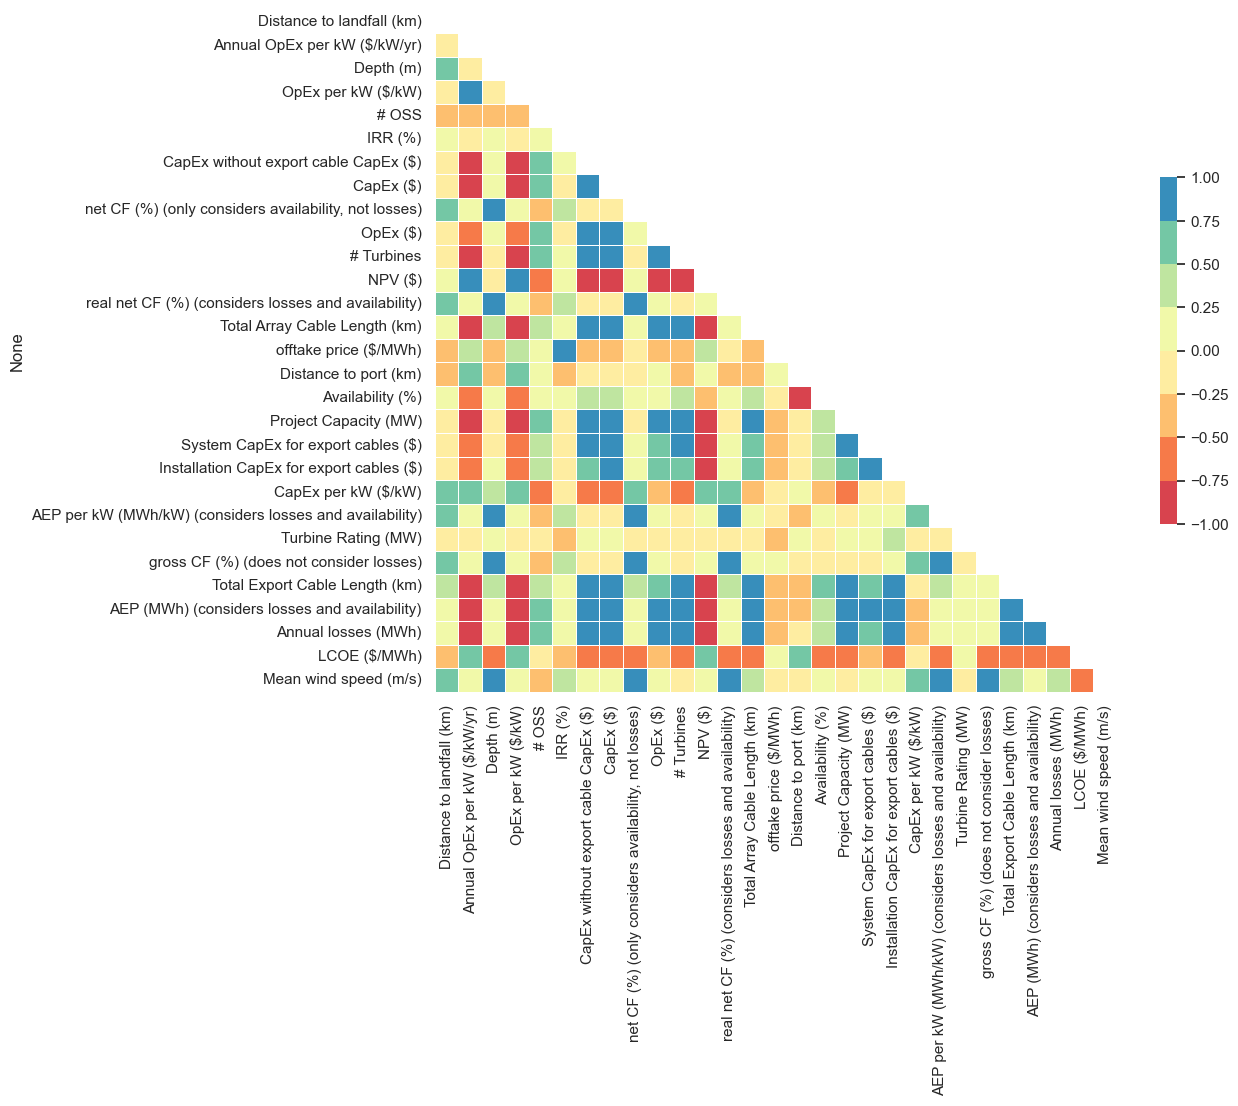

In [15]:
sns.set_theme(style="white")
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111)

mask = np.triu(np.ones_like(corr_df.values, dtype=bool))
cmap = sns.diverging_palette(145, 300, s=60)
cmap = sns.color_palette("Spectral", n_colors=8)

sns.heatmap(corr_df, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.show()